# Deep Learning Diabetes Classification

이 노트북은 `wine_dl_classification.ipynb` 샘플 코드를 참고하여 `diabetes.csv` 데이터의 `Outcome`을 분류하는 딥러닝 모델을 구현합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# 1. 데이터 로드
df = pd.read_csv('csv/diabetes.csv')
print("Data Shape:", df.shape)
df.head()

Data Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# 2. 데이터 전처리
# Outcome 컬럼이 타겟(y), 나머지가 피처(X)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 피처 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 타겟 원-핫 인코딩 (샘플 코드 방식 유지)
Y_onehot = pd.get_dummies(y).values

# 3. 데이터 분할 (학습:테스트 = 8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_onehot, test_size=0.2, random_state=0
)

In [10]:
# 4. 모델 구축
# 입력부터 출력까지 한 방향으로 데이터를 쌓는 모델 구축 (Sequential)
model = models.Sequential([
    # 첫번째 레이어의 노드를 64개로 설정
    # 활성화 함수로 ReLU를 사용합니다. 입력값이 0보다 작으면 0을, 0보다 크면 그 값을 그대로 내보내어 모델에 비선형성을 부여합니다
    # (딥러닝에서 가장 표준적인 함수)
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    # 학습 과정에서 무작위로 30%의 노드를 끕니다.
    # 이는 특정 노드에만 의존하는 현상을 막아 훈련 데이터에만 너무 맞춰지는 현상인 과적합(Overfitting)을 방지하는 역할을 합니다.
    #X_train.shape[0] -> 행(row), X_train.shape[1] -> 열(column)
    layers.Dropout(0.3),
    # 두번째 레이어 노드는 32개로 모델이 더 복잡한 패턴을 학습 가능하게 함
    layers.Dense(32, activation="relu"),
    # Y_onehot.shape[0] -> 행(row), Y_onehot.shape[1] -> 열(column)
    # activation='softmax' -> 출력값을 확률로 변환
    # ex) [0.1, 0.9] -> 확률이 90%이다
    layers.Dense(Y_onehot.shape[1], activation="softmax")   # 클래스 수(2)에 맞춤
])

# 5. 모델 컴파일
model.compile(
    # 모델이 정답과 예측값 사이의 오차를 줄이기 위해 가중치(Weight)를 어떻게 업데이트할지 결정하는 최적화 알고리즘
    optimizer="adam",
    # one-hot 인코딩은 결과를 리스트형태로 저장하기 때문에 사용하는 손실함수는 categorical_crossentropy임
    loss="categorical_crossentropy",
    # 정확도를 기준으로 성능을 보여달라는 설정
    metrics=["accuracy"]
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,722 (10.63 KB)

 Trainable params: 2,722 (10.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 6. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9796 - loss: 0.0622 - val_accuracy: 0.6748 - val_loss: 4.4155
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9796 - loss: 0.0531 - val_accuracy: 0.6748 - val_loss: 4.3667
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9837 - loss: 0.0407 - val_accuracy: 0.6667 - val_loss: 4.3693
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9898 - loss: 0.0412 - val_accuracy: 0.6667 - val_loss: 4.3233
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9776 - loss: 0.0651 - val_accuracy: 0.6748 - val_loss: 4.4985
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9837 - loss: 0.0426 - val_accuracy: 0.6829 - val_loss: 4.4329
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9796 - loss: 0.0565 - val_accuracy: 0.6829 - val_loss: 4.3824
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9817 - loss: 0.0477 - val_accuracy: 0.6748 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


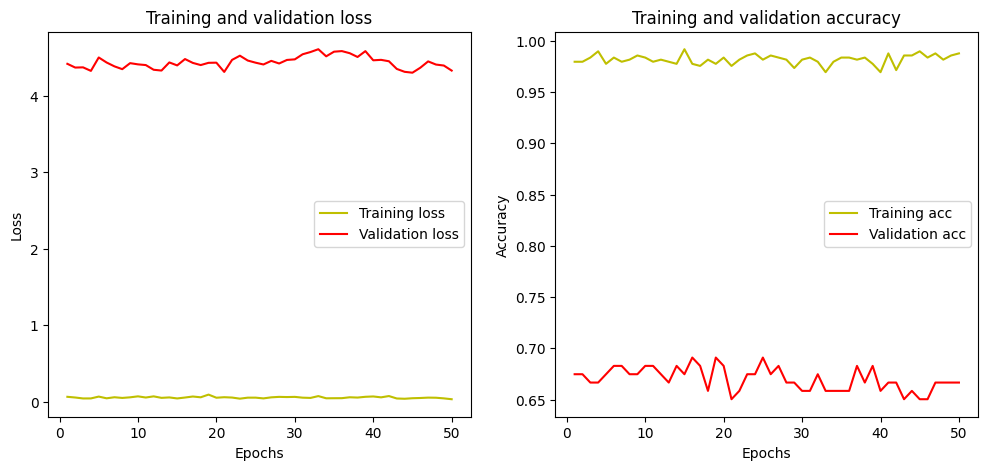

In [18]:
# 7. 예측 및 평가
y_pred = model.predict(X_test)

# 원-핫 인코딩된 결과를 다시 클래스 번호로 변환
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 8. 학습 곡선 시각화
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       107
           1       0.55      0.55      0.55        47

    accuracy                           0.73       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:


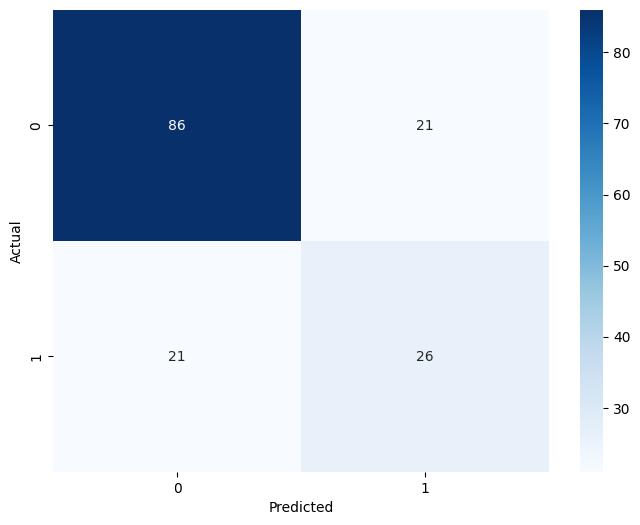

In [9]:
# 9. 성능 보고서 및 혼동 행렬
print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()